#### Import Libraries

In [569]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#### Load Data

In [570]:
yelp = pd.read_csv("hotel_final.csv")

yelp.head()

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,"My husband took me to stay the night for a fun date night one year and I'm finally getting around to writing a review of this place. Well, it's the W hotel, which obviously means it's stylish, cool, trendy, all in once place with an exceptional location in Chi-town overlooking Lake Michigan. We were there in the winter so I can't speak for spending time outside the hotel facilities so we definitely took full advantage of the inside. The people at the lobby were super nice, the decor was fab-u-lous throughout and the actual hotel room was spacious, clean and had a very chic feel to it. We left as happy guests. The best part of the hotel is that it houses Wave restaurant which is like Mediterranean tapas and it's absolutely delicious and definitely cost effective. This 4 star hotel is a great location to stay for both tourists, locals and even if you're on business trips, the concierge will be friendly and polite and the bar is definitely worth checking out and if time allows, make a reservation at Wave. And I have to mention that I got a really good night's sleep when we stayed our one night, bed was super comfy and those pillows, I was seriously contemplating taking them home with me.",4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a fantastic rate on priceline. We took the blue line to Clark/Lake and then took the taxi to the hotel. Check in process was smooth, we had a wonderful room with a view of buildings across the street. Room was nicely furnished, flat screen, high beds, window shades between bedroom and bathroom. The room smelled nice and the furnishings were in a fine condition. We got a glimpse of the rooms with a view from the elevator waiting area - it looks our directly at a beautiful beach with Navy Pier to the right. I can imagine how amazing it must be to wake up with that view in the morning. It was raining on Friday night, we asked to use the hotel umbrella when we went out for dinner but apparently they were all out. The agent at the front desk offered us her personally umbrella but we declined (I think her name was Arianna - great service). We also had forgotten the charger for our iPhones, although they weren't able to send us one for our room, it was no problem to stop by the front desk and leave it there to charge in the back. We did that for 2 nights. The welcome desk was a little chaotic the two times we needed to speak to them, and when we did their attitude wasn't entirely pleasant. That was the only minor flaw to the hotel besides the unusually slow elevators that seemed to stop at every floor every time we needed to go to the lobby. We had plans all weekend, so didn't get to use the pool, restaurants or bars on site. We rented a zip car for 2 hours for our little excursion on Hot Doug's on Saturday morning. The car was parked a block away in a lot, very convenient. Other times we took the Red line (Chicago), explored the city on foot, and at the end of the night we took the taxi to the hotel. The W Lakeshore is located a bit far from the river and Michigan Ave. but the lake view is simply breath taking. If the weather was warmer, the pedestrian path by the lake and the beach is just across the street. Perfect for someone who wants to go for a jog or just relax by the water.",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of the W concept. This hotel has both good and bad. The rooms are very updated and comfortable, but- the soundproofing stinks. Had to swicth rooms and still was awakended by noise the next morning. The staff is very friendly, but- they are so friendly it takes them forever to check you in, so the folks behind you get to wait. The location next to the lake is great, especially if you have a lakeview, but- it's also far from everything else, with few amenities in immediate walking distance. Probably will hit up th

#### Inspect Data

In [571]:
print(yelp.shape)
print(yelp.columns)
yelp.info()
yelp.head()

(949, 7)
Index(['Unnamed: 0', 'reviewID', 'reviewContent', 'rating', 'usefulCount',
       'coolCount', 'funnyCount'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     949 non-null    int64 
 1   reviewID       949 non-null    object
 2   reviewContent  949 non-null    object
 3   rating         949 non-null    int64 
 4   usefulCount    949 non-null    int64 
 5   coolCount      949 non-null    int64 
 6   funnyCount     949 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 52.0+ KB


,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,"My husband took me to stay the night for a fun date night one year and I'm finally getting around to writing a review of this place. Well, it's the W hotel, which obviously means it's stylish, cool, trendy, all in once place with an exceptional location in Chi-town overlooking Lake Michigan. We were there in the winter so I can't speak for spending time outside the hotel facilities so we definitely took full advantage of the inside. The people at the lobby were super nice, the decor was fab-u-lous throughout and the actual hotel room was spacious, clean and had a very chic feel to it. We left as happy guests. The best part of the hotel is that it houses Wave restaurant which is like Mediterranean tapas and it's absolutely delicious and definitely cost effective. This 4 star hotel is a great location to stay for both tourists, locals and even if you're on business trips, the concierge will be friendly and polite and the bar is definitely worth checking out and if time allows, make a reservation at Wave. And I have to mention that I got a really good night's sleep when we stayed our one night, bed was super comfy and those pillows, I was seriously contemplating taking them home with me.",4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a fantastic rate on priceline. We took the blue line to Clark/Lake and then took the taxi to the hotel. Check in process was smooth, we had a wonderful room with a view of buildings across the street. Room was nicely furnished, flat screen, high beds, window shades between bedroom and bathroom. The room smelled nice and the furnishings were in a fine condition. We got a glimpse of the rooms with a view from the elevator waiting area - it looks our directly at a beautiful beach with Navy Pier to the right. I can imagine how amazing it must be to wake up with that view in the morning. It was raining on Friday night, we asked to use the hotel umbrella when we went out for dinner but apparently they were all out. The agent at the front desk offered us her personally umbrella but we declined (I think her name was Arianna - great service). We also had forgotten the charger for our iPhones, although they weren't able to send us one for our room, it was no problem to stop by the front desk and leave it there to charge in the back. We did that for 2 nights. The welcome desk was a little chaotic the two times we needed to speak to them, and when we did their attitude wasn't entirely pleasant. That was the only minor flaw to the hotel besides the unusually slow elevators that seemed to stop at every floor every time we needed to go to the lobby. We had plans all weekend, so didn't get to use the pool, restaurants or bars on site. We rented a zip car for 2 hours for our little excursion on Hot Doug's on Saturday morning. The car was parked a block away in a lot, very convenient. Other times we took the Red line (Chicago), explored the city on foot, and at the end of the night we took the taxi to the hotel. The W Lakeshore is located a bit far from the river and Michigan Ave. but the lake view is simply breath taking. If the weather was warmer, the pedestrian path by the lake and the beach is just across the street. Perfect for someone who wants to go for a jog or just relax by the water.",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of the W concept. This hotel has both good and bad. The rooms are very updated and comfortable, but- the soundproofing stinks. Had to swicth rooms and still was awakended by noise the next morning. The staff is very friendly, but- they are so friendly it takes them forever to check you in, so the folks behind you get to wait. The location next to the lake is great, especially if you have a lakeview, but- it's also far from everything else, with few amenities in immediate walking distance. Probably will hit up th

#### Check for  Missing Values

In [572]:
yelp.isnull().sum()

Unnamed: 0       0
reviewID         0
reviewContent    0
rating           0
usefulCount      0
coolCount        0
funnyCount       0
dtype: int64

#### Create Sentiment Groups

In [573]:
def sentGroup(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

yelp["sentGroup"] = yelp["rating"].apply(sentGroup)

yelp["sentGroup"].value_counts()

sentGroup
Positive    540
Neutral     207
Negative    202
Name: count, dtype: int64

#### Visualize Rating  Distribution

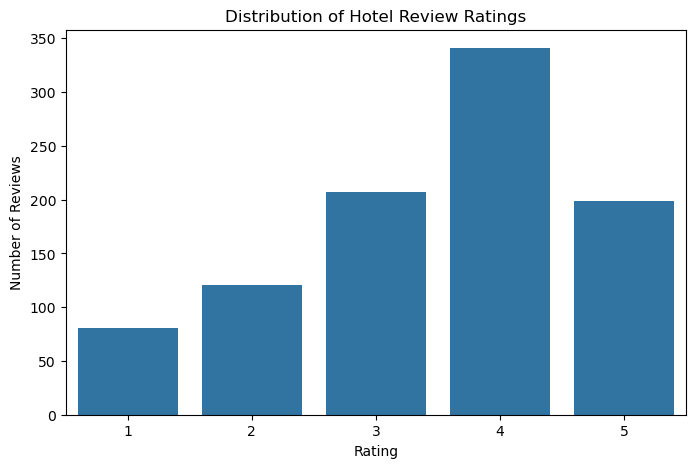

In [574]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "rating")
plt.title("Distribution of Hotel Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

#### Visualize Sentiment Distribution

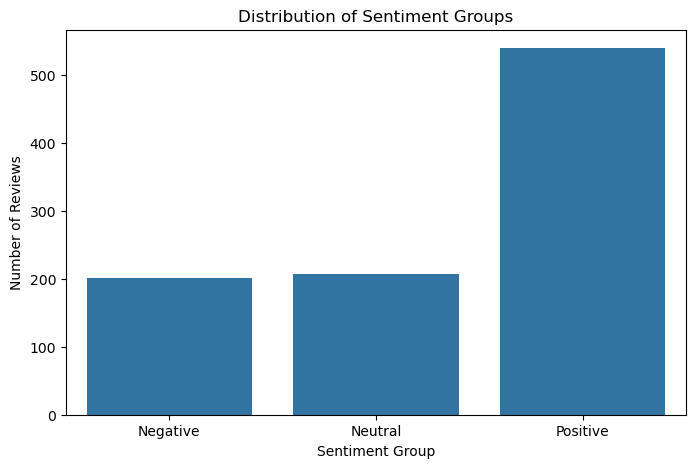

In [575]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "sentGroup", order=["Negative", "Neutral", "Positive"])
plt.title("Distribution of Sentiment Groups")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Reviews")
plt.show()

#### Clean Review Text

In [576]:
stopWords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

customStopwords = {
    "hotel", "room", "stay", "stayed", "night", "place", "would",
    "could", "also", "one", "get", "us", "like", "chicago", "house", "palmer", "even",
    "great", "nice", "good", "really", "got", "well", "day", "told"
}

stopWords = stopWords.union(customStopwords)

def cleanText(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stopWords and len(word) > 2
    ]
    
    return " ".join(words)

yelp["cleanReview"] = yelp["reviewContent"].apply(cleanText)

yelp[["reviewContent", "cleanReview"]].head()

,reviewContent,cleanReview
0,"My husband took me to stay the night for a fun date night one year and I'm finally getting around to writing a review of this place. Well, it's the W hotel, which obviously means it's stylish, cool, trendy, all in once place with an exceptional location in Chi-town overlooking Lake Michigan. We were there in the winter so I can't speak for spending time outside the hotel facilities so we definitely took full advantage of the inside. The people at the lobby were super nice, the decor was fab-u-lous throughout and the actual hotel room was spacious, clean and had a very chic feel to it. We left as happy guests. The best part of the hotel is that it houses Wave restaurant which is like Mediterranean tapas and it's absolutely delicious and definitely cost effective. This 4 star hotel is a great location to stay for both tourists, locals and even if you're on business trips, the concierge will be friendly and polite and the bar is definitely worth checking out and if time allows, make a reservation at Wave. And I have to mention that I got a really good night's sleep when we stayed our one night, bed was super comfy and those pillows, I was seriously contemplating taking them home with me.",husband took fun date year finally getting around writing review obviously mean stylish cool trendy exceptional location chi town overlooking lake michigan winter speak spending time outside facility definitely took full advantage inside people lobby super decor fab lous throughout actual spacious clean chic feel left happy guest best part house wave restaurant mediterranean tapa absolutely delicious definitely cost effective star location tourist local business trip concierge friendly polite bar definitely worth checking time allows make reservation wave mention sleep bed super comfy pillow seriously contemplating taking home
1,"stayed at the property over the weekend, got a fantastic rate on priceline. We took the blue line to Clark/Lake and then took the taxi to the hotel. Check in process was smooth, we had a wonderful room with a view of buildings across the street. Room was nicely furnished, flat screen, high beds, window shades between bedroom and bathroom. The room smelled nice and the furnishings were in a fine condition. We got a glimpse of the rooms with a view from the elevator waiting area - it looks our directly at a beautiful beach with Navy Pier to the right. I can imagine how amazing it must be to wake up with that view in the morning. It was raining on Friday night, we asked to use the hotel umbrella when we went out for dinner but apparently they were all out. The agent at the front desk offered us her personally umbrella but we declined (I think her name was Arianna - great service). We also had forgotten the charger for our iPhones, although they weren't able to send us one for our room, it was no problem to stop by the front desk and leave it there to charge in the back. We did that for 2 nights. The welcome desk was a little chaotic the two times we needed to speak to them, and when we did their attitude wasn't entirely pleasant. That was the only minor flaw to the hotel besides the unusually slow elevators that seemed to stop at every floor every time we needed to go to the lobby. We had plans all weekend, so didn't get to use the pool, restaurants or bars on site. We rented a zip car for 2 hours for our little excursion on Hot Doug's on Saturday morning. The car was parked a block away in a lot, very convenient. Other times we took the Red line (Chicago), explored the city on foot, and at the end of the night we took the taxi to the hotel. The W Lakeshore is located a bit far from the river and Michigan Ave. but the lake view is simply breath taking. If the weather was warmer, the pedestrian path by the lake and the beach is just across the street. Perfect for someone who wants to go for a jog or just relax by the water.",property weekend fantastic rate priceline took blue line clark lake to

#### Split Data Between Negative, Neutral, and  Positive

In [577]:
positive = yelp[yelp["sentGroup"] == "Positive"].copy()
negative = yelp[yelp["sentGroup"] == "Negative"].copy()
neutral = yelp[yelp["sentGroup"] == "Neutral"].copy()

print("Positive:", positive.shape)
print("Negative:", negative.shape)
print("Neutral:", neutral.shape)

Positive: (540, 9)
Negative: (202, 9)
Neutral: (207, 9)


#### Create Function for Top Words

In [578]:
def getTopWords(textSeries, n = 20):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(textSeries)
    
    wordCounts = X.sum(axis = 0).A1
    words = vectorizer.get_feature_names_out()
    
    wordFreq = pd.DataFrame({
        "word": words,
        "count": wordCounts
    }).sort_values(by = "count", ascending = False)
    
    return wordFreq.head(n)

#### Identify Top Words in Total Dataset

In [579]:
topWords = getTopWords(yelp["cleanReview"], n = 20)
topWords

,word,count
5361,room,549
3693,lobby,460
5586,service,447
6479,time,438
567,bed,408
505,bar,361
3698,location,361
6898,view,347
6016,staff,321
536,bathroom,317


#### Visualize Top Words of Full Cleaned Dataset

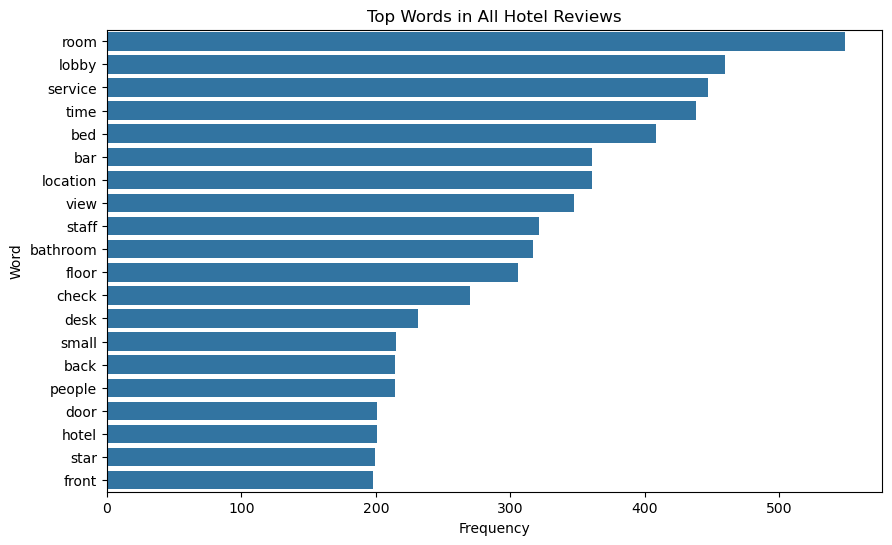

In [580]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWords, x = "count", y = "word")
plt.title("Top Words in All Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Positive Reviews

In [581]:
topWordsPos = getTopWords(positive["cleanReview"], n = 20)
topWordsPos

,word,count
3708,room,285
2524,lobby,260
4487,time,235
333,bar,221
4759,view,215
3863,service,215
2528,location,202
379,bed,184
4165,staff,181
1708,floor,158


#### Visualize Positive Words

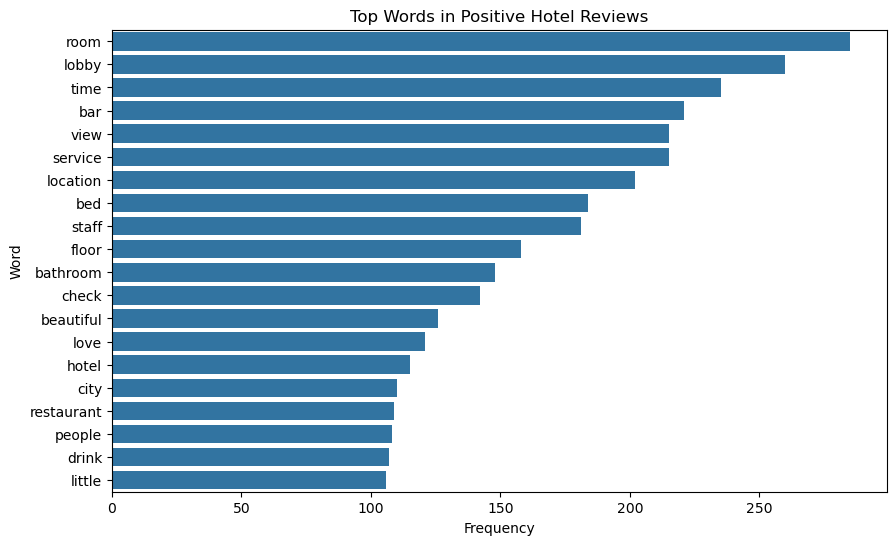

In [582]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsPos, x = "count", y = "word")
plt.title("Top Words in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Negative Reviews

In [583]:
topWordsNeg = getTopWords(negative["cleanReview"], n = 20)
topWordsNeg

,word,count
2832,service,152
2722,room,110
312,bed,108
884,desk,104
3275,time,98
1872,lobby,91
1344,front,90
258,back,82
299,bathroom,77
3037,staff,75


#### Visualize Negative Words

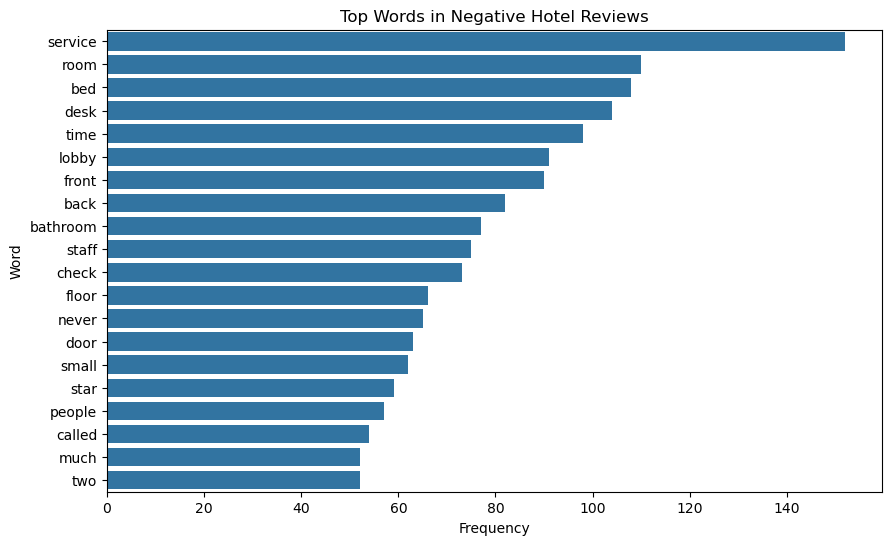

In [584]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsNeg, x = "count", y = "word")
plt.title("Top Words in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Creat Function for Top N-Grams

In [585]:
def getTopNgrams(text_series, ngram_range = (2, 2), n = 20):
    vectorizer = CountVectorizer(ngram_range = ngram_range)
    X = vectorizer.fit_transform(text_series)
    
    counts = X.sum(axis = 0).A1
    phrases = vectorizer.get_feature_names_out()
    
    phrase_freq = pd.DataFrame({
        "phrase": phrases,
        "count": counts
    }).sort_values(by="count", ascending=False)
    
    return phrase_freq.head(n)

#### Identify Top Bigrams in Positive Reviews

In [586]:
posBigrams = getTopNgrams(
    positive["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

posBigrams

,phrase,count
15293,navy pier,55
9628,front desk,51
25110,walking distance,34
13124,lobby bar,31
24820,view lake,28
14668,michigan ave,25
2788,block away,24
14777,millennium park,24
11506,hyatt regency,24
21668,staff friendly,22


#### Visualize Positive Bigrams

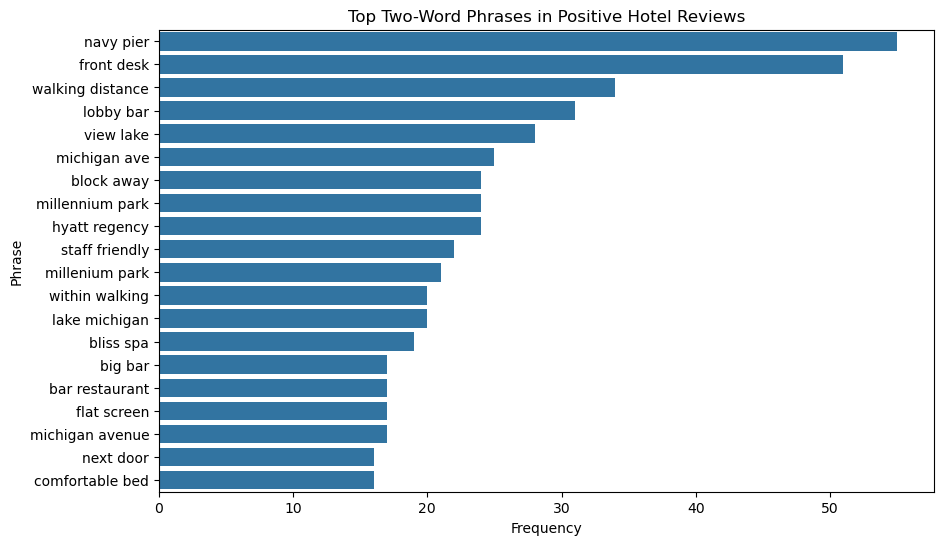

In [587]:
plt.figure(figsize = (10, 6))
sns.barplot(data = posBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Identify Top Bigrams in Negative Reviews

In [588]:
negBigrams = getTopNgrams(
    negative["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

negBigrams

,phrase,count
5172,front desk,76
3124,customer service,21
1900,came back,12
8560,non smoking,12
3751,double bed,11
2592,come back,11
10561,room small,11
8486,next door,11
8307,navy pier,10
8203,much better,9


#### Visuzalize Negative Bigrams

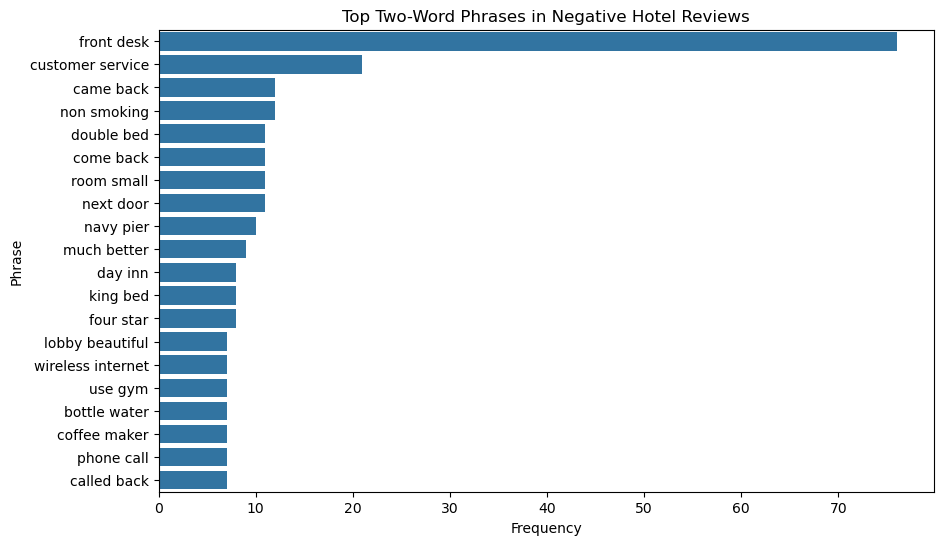

In [589]:
plt.figure(figsize = (10, 6))
sns.barplot(data = negBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Incorporate Review Length Feature

In [590]:
yelp["reviewWordCount"] = yelp["cleanReview"].apply(lambda x: len(x.split()))
yelp["reviewCharCount"] = yelp["reviewContent"].apply(lambda x: len(str(x)))

yelp[["rating", "sentGroup", "reviewWordCount", "reviewCharCount"]].head()

,rating,sentGroup,reviewWordCount,reviewCharCount
0,4,Positive,88,1203
1,3,Neutral,170,2056
2,3,Neutral,48,666
3,3,Neutral,209,2845
4,1,Negative,40,383


#### Compare Review Length By Sentiment

In [591]:
yelp.groupby("sentGroup")[["reviewWordCount", "reviewCharCount"]].mean()

,reviewWordCount,reviewCharCount
sentGroup,,
Negative,80.787129,1074.084158
Neutral,71.014493,940.772947
Positive,58.737037,769.522222


#### Visualize Review Length By Sentiment

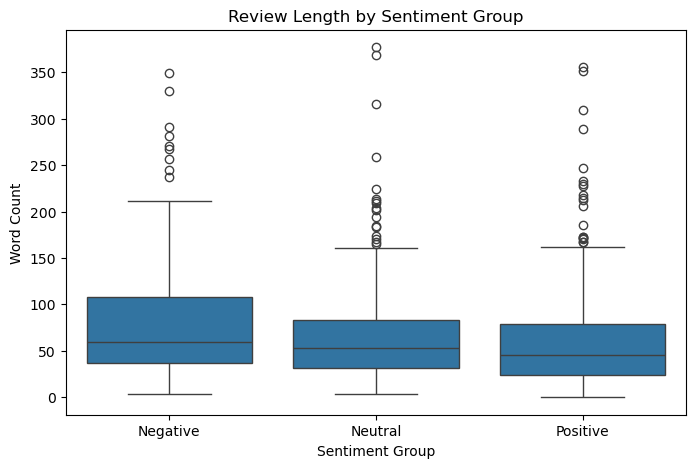

In [592]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = yelp, x = "sentGroup", y = "reviewWordCount", order = ["Negative", "Neutral", "Positive"])
plt.title("Review Length by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Word Count")
plt.show()

#### Create Topic Modeling Function Using LDA

In [593]:
def run_lda_topic_model(text_series, num_topics = 5, num_words = 10):
    vectorizer = CountVectorizer(
        max_df = 0.90,
        min_df = 5,
        stop_words = "english"
    )
    
    X = vectorizer.fit_transform(text_series)
    
    lda = LatentDirichletAllocation(
        n_components = num_topics,
        random_state = 13,
        learning_method = "batch"
    )
    
    lda.fit(X)
    
    feature_names = vectorizer.get_feature_names_out()
    
    topics = []
    
    for topic_num, topic in enumerate(lda.components_):
        top_word_indices = topic.argsort()[-num_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]
        
        topics.append({
            "topic_number": topic_num + 1,
            "top_words": ", ".join(top_words)
        })
    
    topic = pd.DataFrame(topics)
    
    topicMatrix = lda.transform(X)
    
    return lda, vectorizer, topic, topicMatrix

#### LDA Topics for All Reviews

In [594]:
ldaTotal, vectorizerTotal, topicsTotal, topicsTotalMatrix = run_lda_topic_model(
    yelp["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsTotal

,topic_number,top_words
0,1,"service, time, staff, event, mom, food, wife, way, desk, smoking, phone, work"
1,2,"room, lobby, bar, time, view, service, staff, location, pretty, bathroom, beautiful, lake"
2,3,"bed, time, floor, desk, check, service, room, bathroom, door, hyatt, say, star"
3,4,"location, room, parking, lobby, bar, view, free, downtown, bed, park, internet, area"
4,5,"bed, service, room, lobby, location, price, check, time, beautiful, staff, view, internet"


#### LDA Topics for Positive Reviews

In [595]:
ldaPos, vectorizerPos, topicsPos, topicsPosMatrix = run_lda_topic_model(
    positive["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsPos

,topic_number,top_words
0,1,"time, service, bar, room, beautiful, staff, lobby, lot, bed, drink, food, morning"
1,2,"wedding, time, room, parking, lobby, desk, think, service, staff, pretty, floor, beautiful"
2,3,"lobby, time, floor, bar, love, room, drink, staying, free, service, elevator, view"
3,4,"location, room, bed, clean, hyatt, staff, bathroom, walk, park, service, area, block"
4,5,"view, lake, bathroom, bar, room, bliss, love, pier, service, lakeshore, spa, lobby"


#### LDA Topics for Negative Reviews

In [596]:

ldaNeg, vectorizerNeg, topicsNeg, topicsNegMatrix = run_lda_topic_model(
    negative["cleanReview"],
    num_topics = 5,
    num_words = 12
)

topicsNeg

,topic_number,top_words
0,1,"bag, service, guy, people, view, tip, check, parking, hyatt, need, gave, away"
1,2,"lobby, room, floor, bathroom, service, bar, shower, location, time, hotel, staff, elevator"
2,3,"service, door, time, coffee, bed, small, hour, come, lobby, wall, desk, guess"
3,4,"bed, desk, time, staff, check, called, minute, charge, service, come, work, room"
4,5,"room, desk, bed, service, star, check, pay, free, bathroom, said, double, make"


#### Add Dominant Topic to Negative Reviews

In [597]:
negative = negative.reset_index(drop = True)

negative["dominantTopic"] = topicsNegMatrix.argmax(axis = 1) + 1

negative[["rating", "cleanReview", "dominantTopic"]].head()

,rating,cleanReview,dominantTopic
0,1,view location bad service non existent rude someone attention dirty dingy tired room stain sheet wall foul cheap furniture air conditioning erratic loud poor lighting try shave bathroom dimly lit elevator constant barrage music dated atmosphere many better choice cheaper,2
1,1,location atmosphere room comfy view however service absolutely awful unacceptable hectic chaotic expect star let alone frequent patron starwood family absolutely dis concerning concierge know area friendly helpful finally dragged recommendation probably worst meal ever basically googled restaurant closest going unacceptable acura car never available spa enjoyable bar tending staff rude slow elevator took forever elevator conversation another guest initiated conversation disappointing chaotic relaxing glad return hotel,2
2,2,first time staying probably last booked holiday take advantage indoor pool take family downtown restaurant change tiny bathroom unlike renaissance wacker queen size bed plenty squeeze two double barely leave enough move around bad luggage rack put basically put suitcase shelf clothes hand wall mounted organizer bathroom lack real door sliding bamboo door shutter shit wooden shutter wall separating main bathroom front desk service hit miss checking said starwood card place volunteer look provide guidance earn point fact ignored big deal seldom starwood property prefer marriott hilton brand parking steep downtown standard heading navy pier location want michigan ave many restaurant hike ahead,5
3,2,truly disapointed lake view navu pier thats going room okay quite open concept window bathroom open ito bedroom sure need lol lobby hallway dark loud way carded bar upstairs downstairs annoying old enough buy drink,2
4,2,pro view lake michigan food solid combined outdoor seating location location close navy pier michigan ave con room bathroom small upgrade air conditioning obscenely loud according wife room look dated tried hard update used old day inn wife thought smelled smoky switched second carpet cleaner overkill service poor specifically bell desk shuttling new key never happened ultimately headed conrad blackstone still property chi town still figuring best spg option,2


#### Count Dominant Negative Topics

In [598]:
negTopicCount = negative["dominantTopic"].value_counts().sort_index()

negTopicCount

dominantTopic
1    22
2    52
3    28
4    55
5    45
Name: count, dtype: int64

#### Visualize Dominant Negative Topics

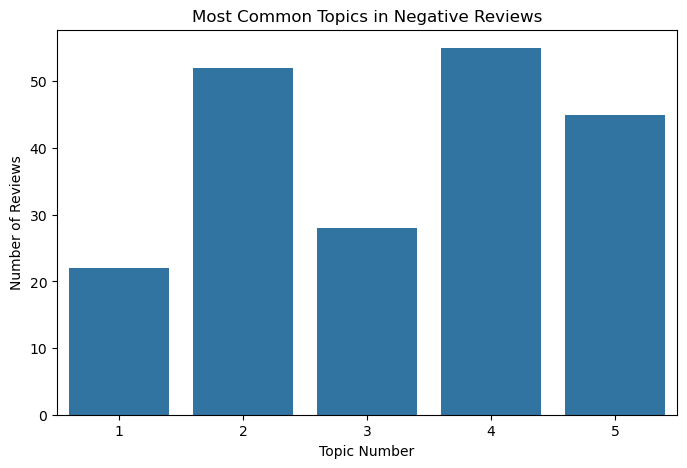

In [599]:
plt.figure(figsize = (8, 5))
sns.barplot(x = negTopicCount.index, y = negTopicCount.values)
plt.title("Most Common Topics in Negative Reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.show()

In [600]:
negTopicLabels = {
    1: "Service Breakdown/Attitude",
    2: "Cleanliness/Wear/Poor Upkeep",
    3: "Design Flaws/Lack of Privacy",
    4: "Noise/Atmosphere Problem",
    5: "Price/Fees/Poor Value"
}

negative["topicLabel"] = negative["dominantTopic"].map(negTopicLabels)

negative[["dominantTopic", "topicLabel", "cleanReview"]].head()

,dominantTopic,topicLabel,cleanReview
0,2,Cleanliness/Wear/Poor Upkeep,view location bad service non existent rude someone attention dirty dingy tired room stain sheet wall foul cheap furniture air conditioning erratic loud poor lighting try shave bathroom dimly lit elevator constant barrage music dated atmosphere many better choice cheaper
1,2,Cleanliness/Wear/Poor Upkeep,location atmosphere room comfy view however service absolutely awful unacceptable hectic chaotic expect star let alone frequent patron starwood family absolutely dis concerning concierge know area friendly helpful finally dragged recommendation probably worst meal ever basically googled restaurant closest going unacceptable acura car never available spa enjoyable bar tending staff rude slow elevator took forever elevator conversation another guest initiated conversation disappointing chaotic relaxing glad return hotel
2,5,Price/Fees/Poor Value,first time staying probably last booked holiday take advantage indoor pool take family downtown restaurant change tiny bathroom unlike renaissance wacker queen size bed plenty squeeze two double barely leave enough move around bad luggage rack put basically put suitcase shelf clothes hand wall mounted organizer bathroom lack real door sliding bamboo door shutter shit wooden shutter wall separating main bathroom front desk service hit miss checking said starwood card place volunteer look provide guidance earn point fact ignored big deal seldom starwood property prefer marriott hilton brand parking steep downtown standard heading navy pier location want michigan ave many restaurant hike ahead
3,2,Cleanliness/Wear/Poor Upkeep,truly disapointed lake view navu pier thats going room okay quite open concept window bathroom open ito bedroom sure need lol lobby hallway dark loud way carded bar upstairs downstairs annoying old enough buy drink
4,2,Cleanliness/Wear/Poor Upkeep,pro view lake michigan food solid combined outdoor seating location location close navy pier michigan ave con room bathroom small upgrade air conditioning obscenely loud according wife room look dated tried hard update used old day inn wife thought smelled smoky switched second carpet cleaner overkill service poor specifically bell desk shuttling new key never happened ultimately headed conrad blackstone still property chi town still figuring best spg option


#### Visualize Labeled Negative Topics

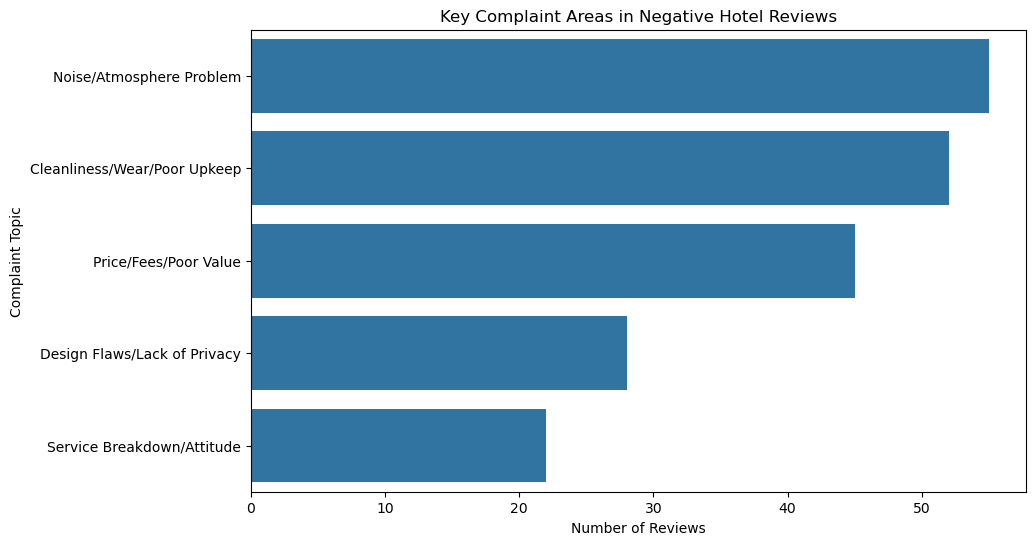

In [601]:
topicLabelCount = negative["topicLabel"].value_counts()

plt.figure(figsize = (10, 6))
sns.barplot(x = topicLabelCount.values, y = topicLabelCount.index)
plt.title("Key Complaint Areas in Negative Hotel Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Complaint Topic")
plt.show()

#### Topic Modeling Function using TF-IDF + NMF

In [602]:
def run_nmf_topic_model(text_series, num_topics = 5, num_words = 10):
    vectorizer = TfidfVectorizer(
        max_df = 0.90,
        min_df = 5,
        stop_words="english"
    )
    
    X = vectorizer.fit_transform(text_series)
    
    nmf = NMF(
        n_components = num_topics,
        random_state = 13
    )
    
    nmf.fit(X)
    
    featureNames = vectorizer.get_feature_names_out()
    
    topics = []
    
    for topicNum, topic in enumerate(nmf.components_):
        topWordIndices = topic.argsort()[-num_words:][::-1]
        topWords = [featureNames[i] for i in topWordIndices]
        
        topics.append({
            "topic_number": topicNum + 1,
            "top_words": ", ".join(topWords)
        })
    
    topicData = pd.DataFrame(topics)
    
    topicMatrix = nmf.transform(X)
    
    return nmf, vectorizer, topicData, topicMatrix

#### NMF Topics for Positive Reviews

In [603]:
nmfPos, tfidfPos, nmfTopicsPos, nmfTopicsPos = run_nmf_topic_model(
    positive["cleanReview"],
    num_topics = 5,
    num_words = 12
)

nmfTopicsPos

array([[0.07875013, 0.0395467 , 0.09303157, 0.03642426, 0.00638556],
       [0.        , 0.14295635, 0.        , 0.        , 0.18353285],
       [0.05863432, 0.02505076, 0.05477706, 0.        , 0.03758604],
       ...,
       [0.11078877, 0.01965465, 0.11915877, 0.        , 0.01403161],
       [0.01564423, 0.01607744, 0.07787859, 0.05920982, 0.02332567],
       [0.        , 0.        , 0.29281675, 0.        , 0.00898157]],
      shape=(540, 5))

#### NMF Topics for Negative Reviews

In [604]:
nmfNeg, tfidfNeg, nmfTopicsNeg, nmfTopicsNeg = run_nmf_topic_model(
    negative["cleanReview"],
    num_topics = 5,
    num_words = 12
)

nmfTopicsNeg

array([[0.10154129, 0.        , 0.        , 0.19958546, 0.        ],
       [0.04601479, 0.14722646, 0.02622882, 0.01531746, 0.        ],
       [0.08081211, 0.05087119, 0.1686506 , 0.        , 0.        ],
       ...,
       [0.0822371 , 0.0093764 , 0.22163698, 0.0484864 , 0.        ],
       [0.12968897, 0.03275323, 0.01156844, 0.        , 0.        ],
       [0.13358602, 0.        , 0.        , 0.        , 0.        ]],
      shape=(202, 5))

#### Compare Average Review Length By Rating

In [605]:
lengthByRating = yelp.groupby("rating")["reviewWordCount"].mean().reset_index()

lengthByRating

,rating,reviewWordCount
0,1,79.839506
1,2,81.421488
2,3,71.014493
3,4,59.724340
4,5,57.045226


#### Plot Average Review Length By Rating

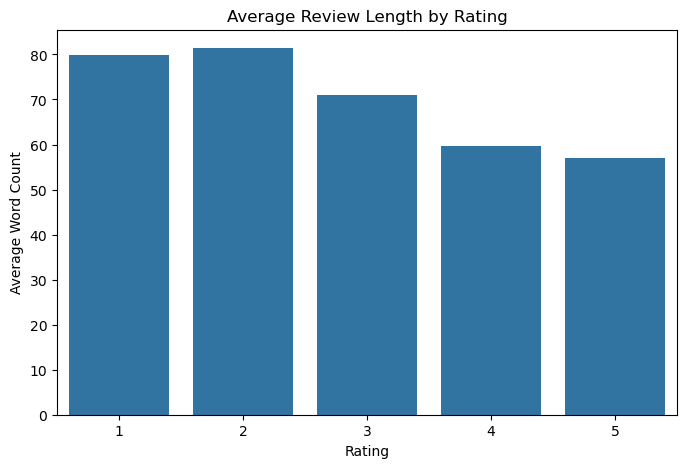

In [606]:
plt.figure(figsize = (8, 5))
sns.barplot(data = lengthByRating, x = "rating", y = "reviewWordCount")
plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Word Count")
plt.show()

#### Identify Common Complaint Phrases Manually

In [607]:
complaintTerms = [
    "dirty",
    "rude",
    "noise",
    "smell",
    "parking",
    "bathroom",
    "bed",
    "service",
    "staff",
    "front desk",
    "fee",
    "expensive",
    "broken",
    "clean"
]

for term in complaintTerms:
    yelp[f"mentions_{term.replace(' ', '_')}"] = yelp["cleanReview"].str.contains(term, regex = False)

#### Compare Complaint Term Mentions By Sentiment

In [608]:
complaintSummary = []

for term in complaintTerms:
    col = f"mentions_{term.replace(' ', '_')}"
    
    summary = yelp.groupby("sentGroup")[col].mean().reset_index()
    summary["term"] = term
    complaintSummary.append(summary)

complaintSummaryData = pd.concat(complaintSummary)

complaintSummaryData.head()

,sentGroup,mentions_dirty,term,mentions_rude,mentions_noise,mentions_smell,mentions_parking,mentions_bathroom,mentions_bed,mentions_service,mentions_staff,mentions_front_desk,mentions_fee,mentions_expensive,mentions_broken,mentions_clean
0,Negative,0.079208,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Neutral,0.014493,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Positive,0.003704,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,rude,0.094059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Neutral,NaN,rude,0.019324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [609]:
# 43. Show complaint terms for negative reviews only

negComplaintRates = complaintSummaryData[
    complaintSummaryData["sentGroup"] == "Negative"
].copy()

negComplaintRates = negComplaintRates.rename(columns = {0: "mentionRate"})

negComplaintRates

,sentGroup,mentions_dirty,term,mentions_rude,mentions_noise,mentions_smell,mentions_parking,mentions_bathroom,mentions_bed,mentions_service,mentions_staff,mentions_front_desk,mentions_fee,mentions_expensive,mentions_broken,mentions_clean
0,Negative,0.079208,dirty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,rude,0.094059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,noise,NaN,0.064356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,smell,NaN,NaN,0.064356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,parking,NaN,NaN,NaN,0.133663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,bathroom,NaN,NaN,NaN,NaN,0.257426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,bed,NaN,NaN,NaN,NaN,NaN,0.331683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,service,NaN,NaN,NaN,NaN,NaN,NaN,0.391089,NaN,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,staff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.247525,NaN,NaN,NaN,NaN,NaN
0,Negative,NaN,front desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.257426,NaN,NaN,NaN,NaN


#### Cleaner Complaint Rate Table

In [610]:
complaintRateTable = []

for term in complaintTerms:
    col = f"mentions_{term.replace(' ', '_')}"
    
    complaintRateTable.append({
        "term": term,
        "negMentionRate": negative["cleanReview"].str.contains(term, regex = False).mean(),
        "posMentionRate": positive["cleanReview"].str.contains(term, regex = False).mean()
    })

complaintRateTable = pd.DataFrame(complaintRateTable)

complaintRateTable["diffNegPos"] = (
    complaintRateTable["negMentionRate"] 
    - complaintRateTable["posMentionRate"]
)

complaintRateTable = complaintRateTable.sort_values(
    by = "diffNegPos",
    ascending = False
)

complaintRateTable

,term,negMentionRate,posMentionRate,diffNegPos
9,front desk,0.257426,0.081481,0.175944
7,service,0.391089,0.296296,0.094793
1,rude,0.094059,0.007407,0.086652
0,dirty,0.079208,0.003704,0.075504
12,broken,0.064356,0.000000,0.064356
10,fee,0.257426,0.205556,0.051870
3,smell,0.064356,0.020370,0.043986
11,expensive,0.094059,0.051852,0.042208
2,noise,0.064356,0.024074,0.040282
4,parking,0.133663,0.098148,0.035515


#### Visualize  Terms That Appear More In Negative Reviews

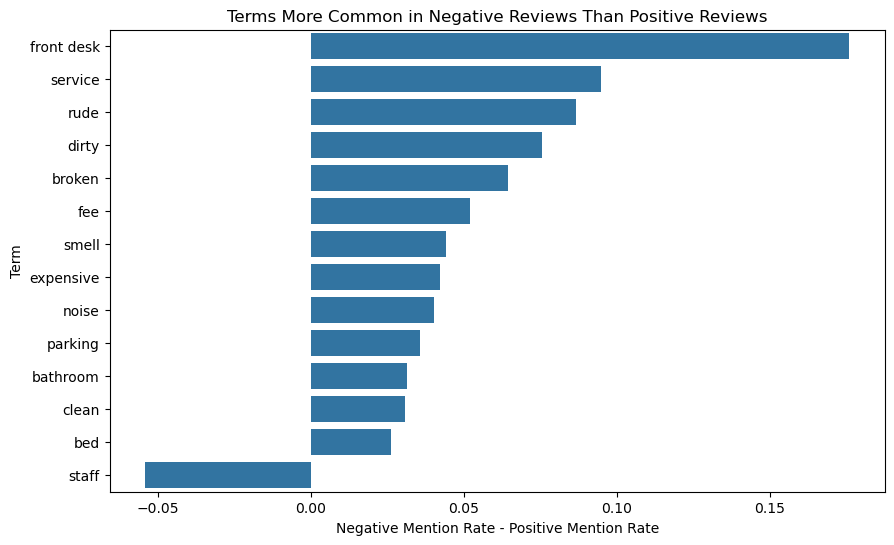

In [611]:
plt.figure(figsize = (10, 6))
sns.barplot(
    data = complaintRateTable,
    x="diffNegPos",
    y="term"
)

plt.title("Terms More Common in Negative Reviews Than Positive Reviews")
plt.xlabel("Negative Mention Rate - Positive Mention Rate")
plt.ylabel("Term")
plt.show()

#### Pull Example Reviews For Each Negative Topic

In [612]:
for topic in sorted(negative["dominantTopic"].unique()):
    print("=" * 80)
    print(f"Topic {topic}: {negTopicLabels.get(topic, 'Unlabeled Topic')}")
    print("=" * 80)
    
    examples = negative[negative["dominantTopic"] == topic]["reviewContent"].head(3)
    
    for i, review in enumerate(examples, start = 1):
        print(f"\nExample {i}:")
        print(review[:700])

Topic 1: Service Breakdown/Attitude

Example 1:
If you are a hot young thing from the suburbs on the make with no need for good bar service, try the lounge! If you are an adult who travels quite a bit and resents paying a substantial chunk of money to be treated like crap by the staff, try another hotel!

Example 2:
I have in fact stayed at some great W Hotels...this is NOT one of them. I may be from Hollywood, but save the game of Dr. Jekyll and Mr. Hyde for someone else...thanks but NO thanks! Let me start off by saying that this is my first ever Yelp review (first of many to come)...the sad part is that such a horrible experience is provoking my first motivation to actually critique a hotel establishment. I'll keep it short and sweet. I travel on a weekly basis for work and pleasure, have stayed in both fantastic and terrible hotels around the world. No story is necessary...when I fly across the country from LA on a weekly basis, I would like to arrive with first class treatment lat

#### Create Summary Tables For Presentation

In [613]:
summaryTable = negative["topicLabel"].value_counts().reset_index()
summaryTable.columns = ["Complaint Topic", "Number of Negative Reviews"]

summaryTable["Percent of Negative Reviews"] = (
    summaryTable["Number of Negative Reviews"] / len(negative) * 100
).round(2)

summaryTable

,Complaint Topic,Number of Negative Reviews,Percent of Negative Reviews
0,Noise/Atmosphere Problem,55,27.23
1,Cleanliness/Wear/Poor Upkeep,52,25.74
2,Price/Fees/Poor Value,45,22.28
3,Design Flaws/Lack of Privacy,28,13.86
4,Service Breakdown/Attitude,22,10.89


#### Export Tables For Slides

In [614]:
topicsTotal.to_csv("topicsAllReviews.csv", index=False)
topicsNeg.to_csv("topicsNegativeReviews.csv", index=False)
topicsPos.to_csv("topicsPositiveReviews.csv", index=False)
summaryTable.to_csv("negReviewTopicSummary.csv", index=False)
complaintRateTable.to_csv("complaintTermComparison.csv", index=False)

In [615]:
recommendations = pd.DataFrame({
    "Category": [
        "Service Breakdown & Staff Indifference",
        "Cleanliness, Wear & Poor Upkeep",
        "Design Flaws & Lack of Privacy",
        "Noise, Atmosphere & Party Environment",
        "Price, Fees & Poor Value"
    ],
    
    "Key Insight": [
        "Guests feel ignored or unsupported during interactions with staff",
        "Rooms appear dirty, worn, or poorly maintained",
        "Room layouts lack privacy and prioritize style over function",
        "Loud environment and party atmosphere disrupt guest experience",
        "Guests feel the experience is not worth the price paid"
    ],
    
    "Recommendations": [
        "Train staff on service recovery; implement KPIs; use mystery shoppers",
        "Conduct housekeeping audits; schedule maintenance; refresh worn interiors",
        "Add privacy features; offer room options; improve transparency in booking",
        "Create quiet zones; enforce noise policies; improve soundproofing",
        "Increase price transparency; reduce hidden fees; add value-based perks"
    ]
})

# Pretty print (clean display)
pd.set_option('display.max_colwidth', None)

recommendations

,Category,Key Insight,Recommendations
0,Service Breakdown & Staff Indifference,Guests feel ignored or unsupported during interactions with staff,Train staff on service recovery; implement KPIs; use mystery shoppers
1,"Cleanliness, Wear & Poor Upkeep","Rooms appear dirty, worn, or poorly maintained",Conduct housekeeping audits; schedule maintenance; refresh worn interiors
2,Design Flaws & Lack of Privacy,Room layouts lack privacy and prioritize style over function,Add privacy features; offer room options; improve transparency in booking
3,"Noise, Atmosphere & Party Environment",Loud environment and party atmosphere disrupt guest experience,Create quiet zones; enforce noise policies; improve soundproofing
4,"Price, Fees & Poor Value",Guests feel the experience is not worth the price paid,Increase price transparency; reduce hidden fees; add value-based perks
